#Entrenamiento de Dataset Para clasificacion de rendimiento academico
Vamos a analizar el dataset ya procesado para que a partir de la informacion de la region y su informacion academica podamos predecir como será en el futuro el cuartil en el cual se encontrará en otro año futuro
- En este colab realizaremos el entrenamiento de los diferentes modelos que vamos a comparar posteriormente para elegir el de mayor rendimiento. Asimismo, realizaremos previamente el preprocesamiento necesario para su aplicación respectiva.

## Configuración del Entorno y Carga de Librerías
En esta sección se importan las herramientas esenciales para la manipulación de datos, visualización y desarrollo de los modelos predictivos. Además, se configuran las preferencias globales del entorno y se vincula el cuaderno con Google Drive para gestionar el almacenamiento de los datasets.

In [ ]:
#Cargamos librerías y cargamos el directorio de trabajo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
warnings.simplefilter(action='ignore', category=FutureWarning)
sns.set(style="whitegrid")
pd.set_option('display.float_format', lambda x: '%.2f' % x)

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def graficar_matriz_confusion(y_true, y_pred, titulo="Matriz de Confusión"):
    """
    Genera un mapa de calor visualmente atractivo para la matriz de confusión.
    """

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))


    ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                     linewidths=.5, cbar=True, annot_kws={"size": 14})


    etiquetas = ['Q1', 'Q2', 'Q3', 'Q4']
    ax.set_xticklabels(etiquetas, fontsize=11)
    ax.set_yticklabels(etiquetas, rotation=0, fontsize=11)


    plt.title(titulo, fontsize=16, pad=15, fontweight='bold')
    plt.ylabel('Cuartil Real', fontsize=12, fontweight='bold')
    plt.xlabel('Cuartil Predicho', fontsize=12, fontweight='bold')


    plt.tight_layout()
    plt.show()



##Lectura del Dataset

In [ ]:
path = '/content/drive/MyDrive/dataset_limpio_preprocesado.csv'
path1 = '/content/drive/MyDrive/FACI/2026-1/IA/TA/dataset_limpio_preprocesado.csv'
path2 = '/content/drive/MyDrive/FACI/2026-1/IA/TA/dataset_limpio_preprocesado2.csv'
path3 = '/content/drive/MyDrive/FACI/2026-1/IA/TA/dataset_limpio_preprocesado3.csv'
#df = pd.read_csv(path, delimiter=',')
df = pd.read_csv(path3, delimiter=',')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 35 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   PROVINCIA                        195 non-null    object 
 1   LECT_EN INICIO_2016              195 non-null    float64
 2   LECT_EN PROCESO_2016             195 non-null    float64
 3   MAT_EN INICIO_2016               195 non-null    float64
 4   MAT_EN PROCESO_2016              195 non-null    float64
 5   MEDIDA PROMEDIO MATEMATICA_2016  195 non-null    float64
 6   LECT_EN INICIO_2018              195 non-null    float64
 7   LECT_EN PROCESO_2018             195 non-null    float64
 8   MAT_EN INICIO_2018               195 non-null    float64
 9   MAT_EN PROCESO_2018              195 non-null    float64
 10  MEDIDA PROMEDIO MATEMATICA_2018  195 non-null    float64
 11  CUARTIL_2024                     195 non-null    int64  
 12  REGION_ANCASH         

##Ajustes Estructurales
Se descarta la variable nominal `PROVINCIA` para conservar únicamente los atributos numéricos y categóricos codificados que alimentarán los modelos entrenados

In [ ]:
df = df.drop('PROVINCIA', axis = 1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   LECT_EN INICIO_2016              195 non-null    float64
 1   LECT_EN PROCESO_2016             195 non-null    float64
 2   MAT_EN INICIO_2016               195 non-null    float64
 3   MAT_EN PROCESO_2016              195 non-null    float64
 4   MEDIDA PROMEDIO MATEMATICA_2016  195 non-null    float64
 5   LECT_EN INICIO_2018              195 non-null    float64
 6   LECT_EN PROCESO_2018             195 non-null    float64
 7   MAT_EN INICIO_2018               195 non-null    float64
 8   MAT_EN PROCESO_2018              195 non-null    float64
 9   MEDIDA PROMEDIO MATEMATICA_2018  195 non-null    float64
 10  CUARTIL_2024                     195 non-null    int64  
 11  REGION_ANCASH                    195 non-null    bool   
 12  REGION_APURIMAC       

#División de datos de entrenamiento y test
Vamos a separar los datos que usaremos para train y test además, definimos una seed para replicar los resultados posteriormente.
**Recordar**:Nuestro target es el cuartil futuro donde se encontrará la *provincia* en 2024 a partir de informacion de 2016 y 2018

In [ ]:
from sklearn.model_selection import train_test_split

#Definimos el split para el entrenamiento y la prueba

X = df.drop('CUARTIL_2024', axis=1)  # atributos
y = df['CUARTIL_2024'] # target

test_size = 0.20
seed = 4   # Número del grupo, seed definido para replicar experimento

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

print('Training: %d registros. Test: %d registros' % (len(y_train), len(y_test)))

Training: 156 registros. Test: 39 registros


##Creacion de los Pipelines a utilizar
En esta parte usaremos los hiperparametros que usaron los papers investigados, además ponemos el parametro `class_weight='balanced'` para que el problema de el desbalance en los datos de clasificacion no afecte al modelo

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline

#Empezamos a crear diferentes pipes para cada modelo

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

pipelines = []
pipelines.append(('LogicReg', make_pipeline(MinMaxScaler(), LogisticRegression(class_weight='balanced', penalty="l2" ))))
pipelines.append(('KNN', make_pipeline(MinMaxScaler(), KNeighborsClassifier( n_neighbors=10, metric='euclidean' ))))
pipelines.append(('DecisionTree', make_pipeline(MinMaxScaler(), DecisionTreeClassifier( class_weight='balanced',max_depth=7 , min_samples_split=2 ))))

##  Diseño de la Estrategia de Validación Cruzada
Para mitigar el sesgo en la estimación del rendimiento y asegurar un proceso de validación robusto ante el tamaño del dataset, se configura una validación cruzada de $K$ iteraciones ($K$-Fold Cross Validation) con 15 particiones. Se fija una semilla usada en train para mantener la consistencia de los subconjuntos.

In [ ]:
from sklearn.model_selection import KFold

#Semilla = Numero del grupo
seed = 42 #semilla usada anteriormente para la separacion de test y train
#NO TOCAR EL KFOLD DEBE SER 42 porque me da buenos resultados asi
kfold = KFold(n_splits=10, random_state=seed, shuffle= True)
kfold


KFold(n_splits=10, random_state=42, shuffle=True)

## Entrenamiento y Evaluación Multimodelo
Se ejecuta el proceso de validación cruzada para cada una de las arquitecturas propuestas. Como métrica de evaluación principal se selecciona `f1_macro`, la cual permite balancear la precisión considerando el desequilibrio que hay dentro de nuestro dataset.

In [ ]:
from sklearn.model_selection import cross_val_score

results = []
names = []

for pipelinename, pipeline in pipelines:
    cv_results = cross_val_score(pipeline, X_train, y_train, cv=kfold, scoring='f1_macro')
    results.append(cv_results)
    names.append(pipelinename)
    print("{}: {} ({})".format(pipelinename, cv_results.mean(), cv_results.std()))

LogicReg: 0.5304008491508492 (0.11011054816234403)
KNN: 0.5097109671374377 (0.11275787935823829)
DecisionTree: 0.44694451381951383 (0.12792467181727157)


##  Comparación Gráfica del Rendimiento
A continuación, se genera un diagrama de cajas y bigotes (*boxplot*) a partir de los puntajes de F1-Score obtenidos en las 15 iteraciones. Esta visualización permite analizar tanto el desempeño promedio como la dispersión y consistencia de cada modelo evaluado.

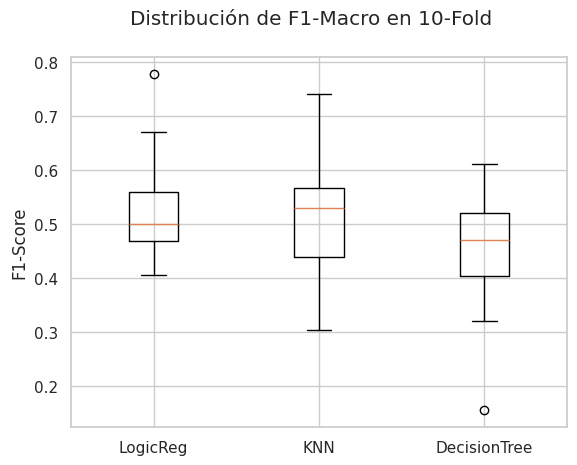

In [ ]:
# Evaluamos gráficamente a partir de los resultados
fig = plt.figure()
fig.suptitle('Distribución de F1-Macro en 10-Fold')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.ylabel('F1-Score') #hace referencia a F1-weighted
plt.show()


Matriz de Confusión:
[[10  3  1  0]
 [ 1  5  1  1]
 [ 0  1  3  3]
 [ 0  2  0  8]]

Reporte de clasificacion en conjunto de validacion:

              precision    recall  f1-score   support

           0       0.91      0.71      0.80        14
           1       0.45      0.62      0.53         8
           2       0.60      0.43      0.50         7
           3       0.67      0.80      0.73        10

    accuracy                           0.67        39
   macro avg       0.66      0.64      0.64        39
weighted avg       0.70      0.67      0.67        39



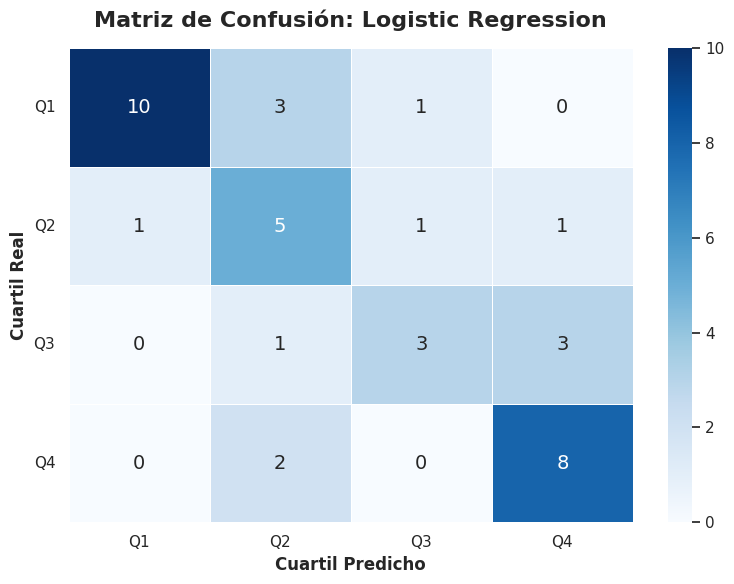

In [ ]:
# @title
pipeline = make_pipeline(MinMaxScaler(), LogisticRegression( class_weight='balanced', penalty="l2" ))

pipeline.fit(X_train, y_train)

y_predicted = pipeline.predict(X_test)
#print("Balanced Accuracy score:", balanced_accuracy_score(y_test, y_predicted))

# muestra la matriz de confusion
# en la matriz de confusion, un elemento Cij es el numero de ejemplos predichos como clase j que son realmente de clase i
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_predicted))

# muestra un reporte de la clasificacion en validacion
print("\nReporte de clasificacion en conjunto de validacion:\n")
print(classification_report(y_test, y_predicted))
graficar_matriz_confusion(y_test, y_predicted, titulo="Matriz de Confusión: Logistic Regression")


**Analisis**: Como podemos observar Logistic Regresion tiene rendimiento relativamente mejor comparado con KNN y decisionTree en el diagrama de cajas. Y eso mismo podemos evidenciarlo tambien en la media de este

## 8. Búsqueda de Hiperparámetros Óptimos
Con el fin de maximizar el rendimiento de los clasificadores, se implementa una búsqueda aleatoria (`RandomizedSearchCV`). Este enfoque evalúa de manera eficiente distintas combinaciones de hiperparámetros en un espacio definido mediante validación cruzada ($K=20$), permitiendo encontrar la configuración más robusta para cada modelo.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Definición de mallas de hiperparámetros
param_grid_lr = {
    'logisticregression__C': [0.01, 0.1, 1, 10, 100],
    'logisticregression__penalty': ['l1', 'l2'],
    'logisticregression__solver': ['saga', 'liblinear']
}

param_grid_knn = {
    'kneighborsclassifier__n_neighbors': list(range(14, 24)),
    'kneighborsclassifier__weights': ['uniform'],
    'kneighborsclassifier__metric': [ 'manhattan', 'minkowski']
}

param_grid_dt = {
    'decisiontreeclassifier__max_depth': [None,2,3,4,8, 10, 15],
    'decisiontreeclassifier__min_samples_split':[ 2,4,3,5, 10,15],

    'decisiontreeclassifier__criterion': ['gini', 'entropy']
}
#'f1_weighted'
# Configuración de los optimizadores
random_search_lr = RandomizedSearchCV(pipelines[0][1], param_distributions=param_grid_lr, n_iter=10, cv=kfold, scoring='f1_macro', random_state=seed, n_jobs=-1)
random_search_knn = RandomizedSearchCV(pipelines[1][1], param_distributions=param_grid_knn, n_iter=15, cv=kfold, scoring='f1_macro', random_state=seed, n_jobs=-1)
random_search_dt = RandomizedSearchCV(pipelines[2][1], param_distributions=param_grid_dt, n_iter=10, cv=kfold, scoring='f1_macro', random_state=seed, n_jobs=-1)

# Ejecución del entrenamiento y búsqueda
print("Optimizando Regresión Logística...")
random_search_lr.fit(X_train, y_train)

print("Optimizando KNN...")
random_search_knn.fit(X_train, y_train)

print("Optimizando Árbol de Decisión...")
random_search_dt.fit(X_train, y_train)

# Despliegue de los mejores resultados
print(f"\nMejor F1 (Regresión Logística): {random_search_lr.best_score_:.4f} usando {random_search_lr.best_params_}")
print(f"Mejor F1 (KNN): {random_search_knn.best_score_:.4f} usando {random_search_knn.best_params_}")
print(f"Mejor F1 (Árbol de Decisión): {random_search_dt.best_score_:.4f} usando {random_search_dt.best_params_}")

Optimizando Regresión Logística...
Optimizando KNN...
Optimizando Árbol de Decisión...

Mejor F1 (Regresión Logística): 0.5343 usando {'logisticregression__solver': 'liblinear', 'logisticregression__penalty': 'l2', 'logisticregression__C': 1}
Mejor F1 (KNN): 0.5301 usando {'kneighborsclassifier__weights': 'uniform', 'kneighborsclassifier__n_neighbors': 17, 'kneighborsclassifier__metric': 'minkowski'}
Mejor F1 (Árbol de Decisión): 0.4964 usando {'decisiontreeclassifier__min_samples_split': 2, 'decisiontreeclassifier__max_depth': 4, 'decisiontreeclassifier__criterion': 'gini'}


##Haciendo el Test final de los modelos

###KNN para el VAB

Balanced Accuracy score: 0.6848214285714286

Matriz de Confusión:
[[13  1  0  0]
 [ 3  5  0  0]
 [ 0  2  2  3]
 [ 0  1  0  9]]

Reporte de clasificacion en conjunto de validacion:

              precision    recall  f1-score   support

           0       0.81      0.93      0.87        14
           1       0.56      0.62      0.59         8
           2       1.00      0.29      0.44         7
           3       0.75      0.90      0.82        10

    accuracy                           0.74        39
   macro avg       0.78      0.68      0.68        39
weighted avg       0.78      0.74      0.72        39



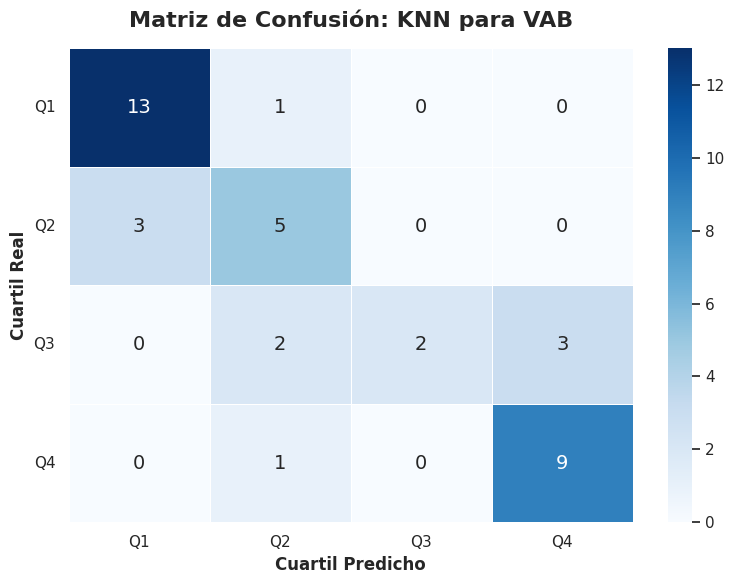

In [ ]:
# @title



# Reentrena el pipeline con con todos los datos de entrenamiento y lo prueba en el conjunto de validación
#KNeighborsClassifier(n_neighbors=17,weights='uniform',metric='minkowski')
pipeline = make_pipeline(MinMaxScaler(), KNeighborsClassifier(n_neighbors=22,weights='uniform',metric='manhattan'))
pipeline.fit(X_train, y_train)

y_predicted = pipeline.predict(X_test)
print("Balanced Accuracy score:", balanced_accuracy_score(y_test, y_predicted))

# muestra la matriz de confusion
# en la matriz de confusion, un elemento Cij es el numero de ejemplos predichos como clase j que son realmente de clase i
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_predicted))

# muestra un reporte de la clasificacion en validacion
print("\nReporte de clasificacion en conjunto de validacion:\n")
print(classification_report(y_test, y_predicted))
graficar_matriz_confusion(y_test, y_predicted, titulo="Matriz de Confusión: KNN para VAB")


###Decision Tree para VAB

Balanced Accuracy score: 0.4455357142857143

Matriz de Confusión:
[[10  3  1  0]
 [ 6  1  1  0]
 [ 1  3  1  2]
 [ 0  1  1  8]]

Reporte de clasificacion en conjunto de validacion:

              precision    recall  f1-score   support

           0       0.59      0.71      0.65        14
           1       0.12      0.12      0.12         8
           2       0.25      0.14      0.18         7
           3       0.80      0.80      0.80        10

    accuracy                           0.51        39
   macro avg       0.44      0.45      0.44        39
weighted avg       0.49      0.51      0.49        39



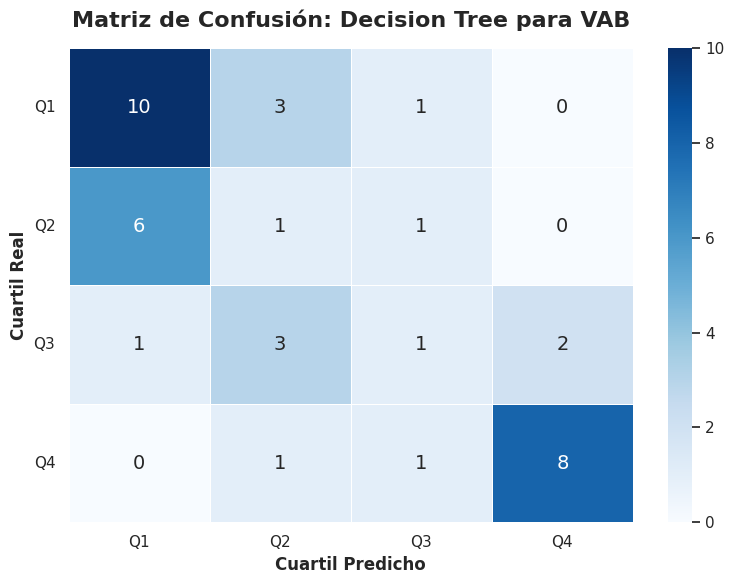

In [ ]:
# @title
pipeline = make_pipeline(MinMaxScaler(), DecisionTreeClassifier( max_depth=8 , min_samples_split=10,criterion='entropy' ))

pipeline.fit(X_train, y_train)

y_predicted = pipeline.predict(X_test)
print("Balanced Accuracy score:", balanced_accuracy_score(y_test, y_predicted))

# muestra la matriz de confusion
# en la matriz de confusion, un elemento Cij es el numero de ejemplos predichos como clase j que son realmente de clase i
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_predicted))

# muestra un reporte de la clasificacion en validacion
print("\nReporte de clasificacion en conjunto de validacion:\n")
print(classification_report(y_test, y_predicted))
graficar_matriz_confusion(y_test, y_predicted, titulo="Matriz de Confusión: Decision Tree para VAB")


###Logistic Regresion para VAB

Balanced Accuracy score: 0.6598214285714286

Matriz de Confusión:
[[11  3  0  0]
 [ 2  5  0  1]
 [ 0  1  3  3]
 [ 0  2  0  8]]

Reporte de clasificacion en conjunto de validacion:

              precision    recall  f1-score   support

           0       0.85      0.79      0.81        14
           1       0.45      0.62      0.53         8
           2       1.00      0.43      0.60         7
           3       0.67      0.80      0.73        10

    accuracy                           0.69        39
   macro avg       0.74      0.66      0.67        39
weighted avg       0.75      0.69      0.69        39



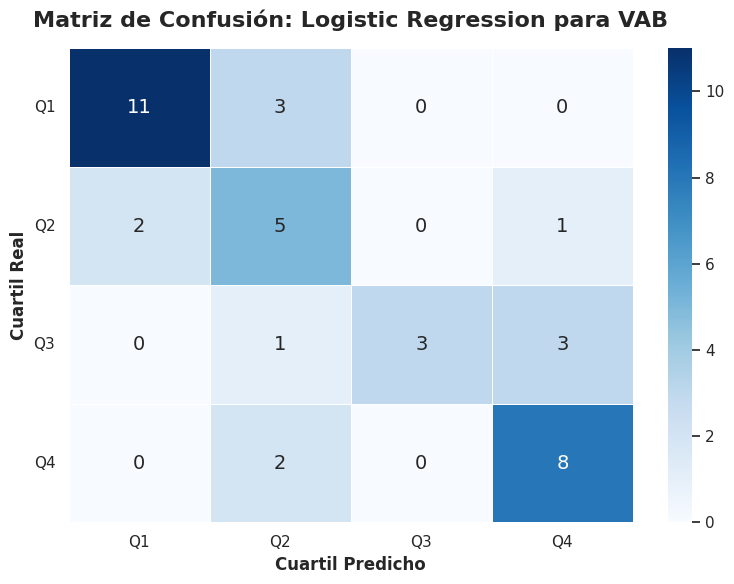

In [ ]:
# @title
pipeline = make_pipeline(MinMaxScaler(), LogisticRegression( C=10 , penalty='l2' , solver='liblinear',class_weight='balanced'))

pipeline.fit(X_train, y_train)

y_predicted = pipeline.predict(X_test)
print("Balanced Accuracy score:", balanced_accuracy_score(y_test, y_predicted))

# muestra la matriz de confusion
# en la matriz de confusion, un elemento Cij es el numero de ejemplos predichos como clase j que son realmente de clase i
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_predicted))

# muestra un reporte de la clasificacion en validacion
print("\nReporte de clasificacion en conjunto de validacion:\n")
print(classification_report(y_test, y_predicted))
graficar_matriz_confusion(y_test, y_predicted, titulo="Matriz de Confusión: Logistic Regression para VAB")


###Logistic Regresion para sin VAB

Balanced Accuracy score: 0.6598214285714286

Matriz de Confusión:
[[11  3  0  0]
 [ 1  5  1  1]
 [ 0  1  3  3]
 [ 0  2  0  8]]

Reporte de clasificacion en conjunto de validacion:

              precision    recall  f1-score   support

           0       0.92      0.79      0.85        14
           1       0.45      0.62      0.53         8
           2       0.75      0.43      0.55         7
           3       0.67      0.80      0.73        10

    accuracy                           0.69        39
   macro avg       0.70      0.66      0.66        39
weighted avg       0.73      0.69      0.70        39



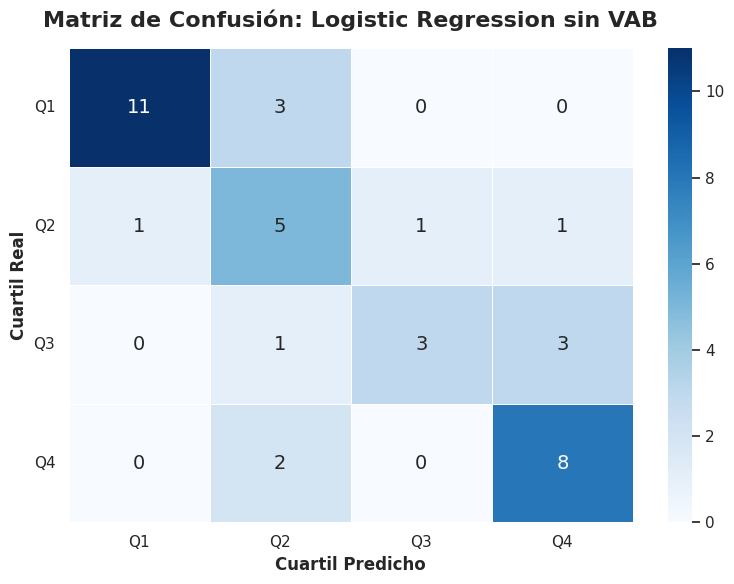

In [ ]:
# @title
# {'logisticregression__solver': 'liblinear', 'logisticregression__penalty': 'l2', 'logisticregression__C': 1}

pipeline = make_pipeline(MinMaxScaler(), LogisticRegression( C=1 , penalty='l2' , solver='liblinear',class_weight='balanced'))

pipeline.fit(X_train, y_train)

y_predicted = pipeline.predict(X_test)
print("Balanced Accuracy score:", balanced_accuracy_score(y_test, y_predicted))

# muestra la matriz de confusion
# en la matriz de confusion, un elemento Cij es el numero de ejemplos predichos como clase j que son realmente de clase i
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_predicted))

# muestra un reporte de la clasificacion en validacion
print("\nReporte de clasificacion en conjunto de validacion:\n")
print(classification_report(y_test, y_predicted))
graficar_matriz_confusion(y_test, y_predicted, titulo="Matriz de Confusión: Logistic Regression sin VAB")


###Decision Tree Para Dataset sin VAB

Balanced Accuracy score: 0.4973214285714286

Matriz de Confusión:
[[8 4 2 0]
 [2 3 3 0]
 [0 3 1 3]
 [0 0 1 9]]

Reporte de clasificacion en conjunto de validacion:

              precision    recall  f1-score   support

           0       0.80      0.57      0.67        14
           1       0.30      0.38      0.33         8
           2       0.14      0.14      0.14         7
           3       0.75      0.90      0.82        10

    accuracy                           0.54        39
   macro avg       0.50      0.50      0.49        39
weighted avg       0.57      0.54      0.54        39



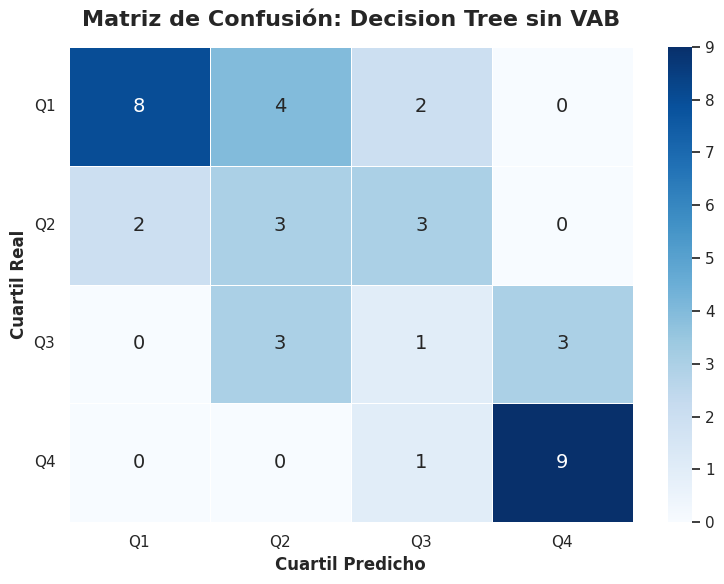

In [ ]:
# @title
pipeline = make_pipeline(MinMaxScaler(), DecisionTreeClassifier( max_depth=4 , min_samples_split=10,criterion='gini' ))

pipeline.fit(X_train, y_train)

y_predicted = pipeline.predict(X_test)
print("Balanced Accuracy score:", balanced_accuracy_score(y_test, y_predicted))

# muestra la matriz de confusion
# en la matriz de confusion, un elemento Cij es el numero de ejemplos predichos como clase j que son realmente de clase i
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_predicted))

# muestra un reporte de la clasificacion en validacion
print("\nReporte de clasificacion en conjunto de validacion:\n")
print(classification_report(y_test, y_predicted))
graficar_matriz_confusion(y_test, y_predicted, titulo="Matriz de Confusión: Decision Tree sin VAB")


###KNN para dataset sin VAB

Balanced Accuracy score: 0.5794642857142858

Matriz de Confusión:
[[12  2  0  0]
 [ 4  3  0  1]
 [ 0  2  2  3]
 [ 0  2  0  8]]

Reporte de clasificacion en conjunto de validacion:

              precision    recall  f1-score   support

           0       0.75      0.86      0.80        14
           1       0.33      0.38      0.35         8
           2       1.00      0.29      0.44         7
           3       0.67      0.80      0.73        10

    accuracy                           0.64        39
   macro avg       0.69      0.58      0.58        39
weighted avg       0.69      0.64      0.63        39



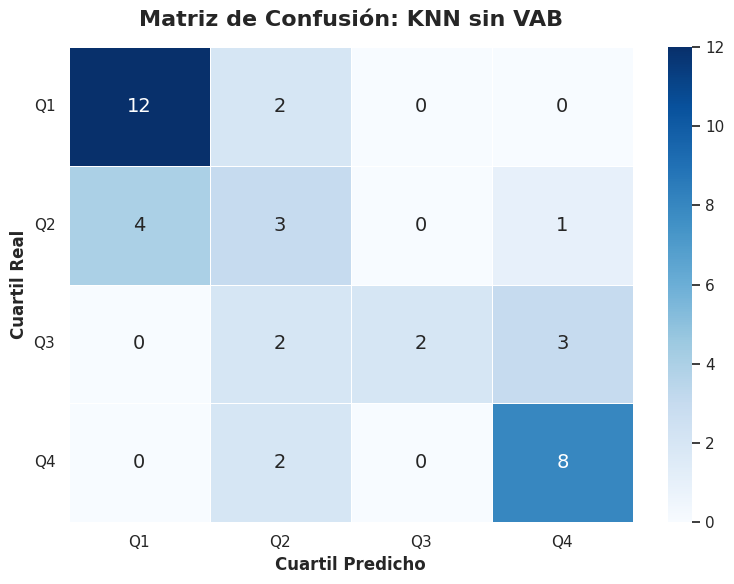

In [ ]:
#{'kneighborsclassifier__weights': 'uniform', 'kneighborsclassifier__n_neighbors': 17, 'kneighborsclassifier__metric': 'minkowski'}
# @title



# Reentrena el pipeline con con todos los datos de entrenamiento y lo prueba en el conjunto de validación
#KNeighborsClassifier(n_neighbors=17,weights='uniform',metric='minkowski')
pipeline = make_pipeline(MinMaxScaler(), KNeighborsClassifier(n_neighbors=17,weights='uniform',metric='minkowski'))
pipeline.fit(X_train, y_train)

y_predicted = pipeline.predict(X_test)
print("Balanced Accuracy score:", balanced_accuracy_score(y_test, y_predicted))

# muestra la matriz de confusion
# en la matriz de confusion, un elemento Cij es el numero de ejemplos predichos como clase j que son realmente de clase i
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_predicted))

# muestra un reporte de la clasificacion en validacion
print("\nReporte de clasificacion en conjunto de validacion:\n")
print(classification_report(y_test, y_predicted))
graficar_matriz_confusion(y_test, y_predicted, titulo="Matriz de Confusión: KNN sin VAB")



#FIN

#Analizando semillas

#ABAJO ES BASURA

#RANDOM FOREST PRUEBA

In [ ]:
# ==========================================
# ENTRENAMIENTO INDEPENDIENTE: RANDOM FOREST
# ==========================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# 1. Definir la malla de hiperparámetros para Random Forest
param_dist = {
    'n_estimators': list(range(100, 200)),
    'max_depth': list(range(1, 25)),
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    #'max_features': ['sqrt', 'log2', None],
   # 'class_weight': ['balanced', 'balanced_subsample', None]
}

# 2. Inicializar el clasificador base
rf_base = RandomForestClassifier(random_state=42)

# 3. Configurar RandomizedSearchCV
# Nota: Usamos scoring='accuracy' para optimizar directamente esta métrica
rf_random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=20,                 # Número de combinaciones aleatorias a probar
    cv=5,                      # Validación cruzada de 5 pliegues para la búsqueda
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,                 # Usar todos los procesadores disponibles
    verbose=1
)

# 4. Ajustar la búsqueda con los datos de entrenamiento existentes
print("Iniciando la búsqueda de mejores parámetros con RandomizedSearch...")
rf_random_search.fit(X_train, y_train)

# 5. Extraer el mejor modelo e hiperparámetros
best_rf_model = rf_random_search.best_estimator_
print("\n--- Mejores Hiperparámetros Encontrados ---")
print(rf_random_search.best_params_)


Iniciando la búsqueda de mejores parámetros con RandomizedSearch...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

--- Mejores Hiperparámetros Encontrados ---
{'n_estimators': 111, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 6}



Accuracy de Random Forest en Test: 0.5641

Reporte de Clasificación (Random Forest):
              precision    recall  f1-score   support

          Q1       0.83      0.71      0.77        14
          Q2       0.29      0.25      0.27         8
          Q3       0.14      0.14      0.14         7
          Q4       0.69      0.90      0.78        10

    accuracy                           0.56        39
   macro avg       0.49      0.50      0.49        39
weighted avg       0.56      0.56      0.56        39



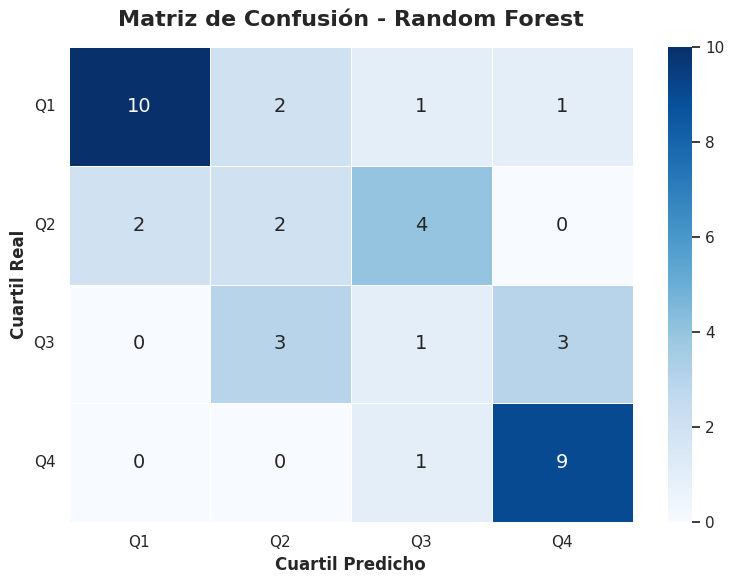

In [ ]:

# 6. Evaluar el modelo optimizado en el conjunto de prueba (X_test)
y_pred_rf = best_rf_model.predict(X_test)

# Calcular y mostrar el Accuracy final
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\n========================================")
print(f"Accuracy de Random Forest en Test: {accuracy_rf:.4f}")
print(f"========================================")

# Mostrar reporte completo de clasificación para ver rendimiento por cuartil
print("\nReporte de Clasificación (Random Forest):")
print(classification_report(y_test, y_pred_rf, target_names=['Q1', 'Q2', 'Q3', 'Q4']))

# Opcional: Graficar su matriz de confusión usando la función predefinida de tu colab
try:
    graficar_matriz_confusion(y_test, y_pred_rf, titulo="Matriz de Confusión - Random Forest")
except NameError:
    print("La función 'graficar_matriz_confusion' no está cargada en el entorno.")